# How Far Is the Horizon?

## Geometry on a Perfect Sphere

When you stand at height **h** above the Earth's surface and look toward the horizon, your line of sight is tangent to the sphere at the horizon point. This forms a right triangle:

- One leg is the Earth's radius **R** (from the center to the tangent point)
- The hypotenuse is **R + h** (from the center to your eye)
- The other leg is the line-of-sight distance to the horizon **d**

## Formula

$$d = \sqrt{(R+h)^2 - R^2} = \sqrt{2Rh + h^2}$$

For small heights where **h ≪ R**, this approximates to:

$$d \approx \sqrt{2Rh} \approx 3.57 \times \sqrt{h} \text{ km}$$

where **h** is in meters.

In [1]:
import math

# Mean Earth radius in meters
EARTH_RADIUS_M = 6_371_000


def horizon_distance_m(h_m, earth_radius_m=EARTH_RADIUS_M):
    """Line-of-sight distance to the horizon in meters."""
    return math.sqrt(2 * earth_radius_m * h_m + h_m**2)


def horizon_distance_km(h_m, earth_radius_m=EARTH_RADIUS_M):
    """Line-of-sight distance to the horizon in kilometers."""
    return horizon_distance_m(h_m, earth_radius_m) / 1000

## Notes and References

- This calculation assumes Earth is a perfect sphere with no atmospheric refraction.
- Real-world visibility is slightly farther due to refraction, which bends light downward.
- See the [geometric horizon](https://en.wikipedia.org/wiki/Horizon#Geometrical_distance_to_the_horizon) article for more background.
- Eye height **h** is measured from the surface (ground level, water level, etc.) to the observer's eyes.

## Create and Display the Plot

Saved plot to /workspace/horizon-distance/horizon_distance.png


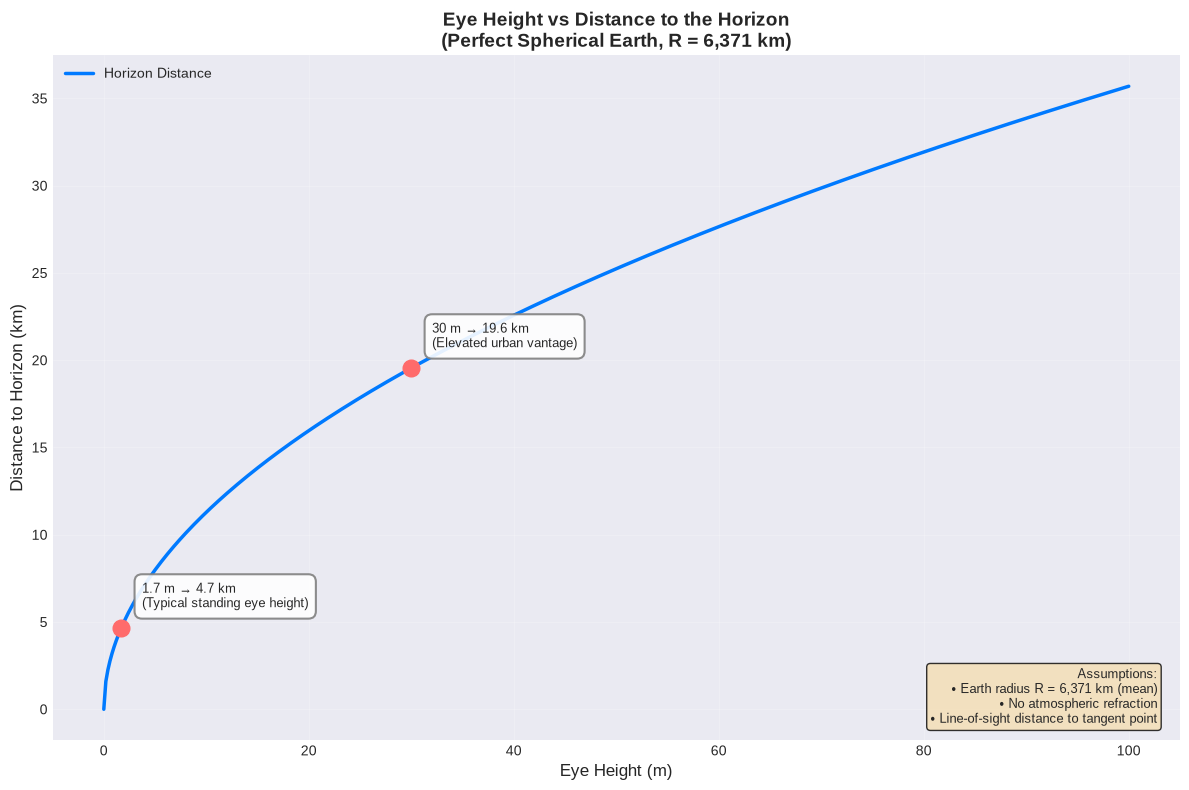

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set up plotting style (try seaborn, fallback to default)
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('default')
        print("Using default matplotlib style")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

eye_heights_m = np.linspace(0, 100, 500)
horizon_distances_km = [horizon_distance_km(h) for h in eye_heights_m]
ax.plot(eye_heights_m, horizon_distances_km, linewidth=2.5, color='#007AFF',
        label='Horizon Distance')

reference_points = {
    'Average adult: 1.7 m': (1.7, horizon_distance_km(1.7), 'Typical standing eye height'),
    '10th floor: 30 m': (30, horizon_distance_km(30), 'Elevated urban vantage'),
    'Burj Khalifa deck: 828 m': (828, horizon_distance_km(828), 'Beyond plot range'),
}

for label, (height, distance, description) in reference_points.items():
    if height <= 100:
        ax.plot(height, distance, 'o', markersize=12, zorder=5, color='#FF6B6B')
        ax.annotate(
            f'{height:g} m → {distance:.1f} km\n({description})',
            xy=(height, distance),
            xytext=(15, 15),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='white',
                      edgecolor='gray', alpha=0.9, linewidth=1.5),
            fontsize=9,
            ha='left',
        )

ax.set_xlabel('Eye Height (m)', fontsize=12)
ax.set_ylabel('Distance to Horizon (km)', fontsize=12)
ax.set_title('Eye Height vs Distance to the Horizon\n(Perfect Spherical Earth, R = 6,371 km)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

source_text = (
    'Assumptions:\n'
    '• Earth radius R = 6,371 km (mean)\n'
    '• No atmospheric refraction\n'
    '• Line-of-sight distance to tangent point'
)
ax.text(0.98, 0.02, source_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()

output_path = Path('horizon_distance.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"Saved plot to {output_path.resolve()}")

plt.show()